In [95]:
import pandas as pd
import datetime
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# make network graph
import plotly.graph_objects as go
import networkx as nx
import matplotlib.pyplot as plt


In [ ]:
firewall_df = pd.read_csv('DC4-data/Firewall/Firewall-04062012.csv')
firewall_df['Date/time'] = pd.to_datetime(firewall_df['Date/time'])
firewall_df.head()

In [9]:
def ip_type(ip_addr):
    ip_addr_split = ip_addr.split('.')

    DNS_Root_Servers = ['198.41.0.4', '128.9.0.107', '192.33.4.12', '128.8.10.90', '192.203.230.10', '192.5.5.241', '192.112.36.4', '128.63.2.53', '192.36.148.17', '192.58.128.30', '193.0.14.129', '198.32.64.12', '202.12.27.33']
    if ip_addr in DNS_Root_Servers:
        return "DNS Root Server"
    
    website = False
    if ip_addr_split[0] == '10' and ip_addr_split[1] == '32':
        if ip_addr_split[2] == '0' and int(ip_addr_split[3]) >= 201 and int(ip_addr_split[3]) <= 210:
            website = True
        if ip_addr_split[2] == '1' and (ip_addr_split[3] == '100' or (int(ip_addr_split[3]) >= 201 and int(ip_addr_split[3]) <= 206)):
            website = True
        if ip_addr_split[2] == '5':
            website = True
    if website:
        return "website"
    
    if ip_addr == '10.32.0.1':
        return "Cisco ASA Firewall (external)"
    if ip_addr == '172.23.0.1':
        return "Cisco ASA Firewall (internal)"
    
    if ip_addr == '10.32.2.100' or ip_addr == '10.32.2.101':
        return 'SNAT'
    
    if ip_addr == '10.32.0.100':
        return 'Corporate Firewall (external)'
    
    if ip_addr == '172.25.0.1':
        return 'Corporate Firewall (internal)'
    
    # Regional Bank Network
    if ip_addr_split[0] == '172' and ip_addr_split[1] == '23':
        if int(ip_addr_split[2]) >= 214 and int(ip_addr_split[2]) <= 229:
            return 'Financial Server'
        if ip_addr == '172.23.0.2':
            return 'Log Server'
        if ip_addr == '172.23.0.10':
            return 'Domain Controller / DNS'
        else:
            return 'Workstation'
    
    return 'Other'

In [49]:
# to be used on firewall_df
def label_source_destination(row):
    return f"{ip_type(row['Source IP'])}---{ip_type(row['Destination IP'])}"

# to be used on source_dest_counts
def extract_source_ip(row):
    return row['IP Types'].split('---')[0]
def extract_destination_ip(row):
    return row['IP Types'].split('---')[1]
def weight(row):
    return np.log(row['Frequency'])

In [ ]:
firewall_df['IP Types'] = firewall_df.apply(label_source_destination, axis=1)


From here down, this is what we do for one hour increment

In [123]:
def generate_frequency_table_for_timespan(startTime, endTime):
    firewall_df_filtered = firewall_df.loc[(firewall_df['Date/time'] >= startTime) & (firewall_df['Date/time'] <= endTime)]
    source_dest_counts = pd.DataFrame(firewall_df_filtered['IP Types'].value_counts().reset_index(name='count'))
    source_ips = source_dest_counts.apply(extract_source_ip, axis=1)
    destination_ips = source_dest_counts.apply(extract_destination_ip, axis=1)
    frequency_table = pd.DataFrame()
    frequency_table['Source IP Type'] = source_ips
    frequency_table['Destination IP Type'] = destination_ips
    frequency_table['Frequency'] = source_dest_counts['count']
    freq_total = sum(frequency_table['Frequency'])

    frequency_table['weight'] = frequency_table.apply(weight, axis=1)
    return frequency_table

In [ ]:
generate_frequency_table_for_timespan('2012-04-05 17:51:26', '2012-04-05 18:51:26')

In [129]:
min_datetime = min(firewall_df['Date/time'])

In [130]:
max_datetime = max(firewall_df['Date/time'])

In [ ]:
date_range_hourly = pd.date_range(start=min_datetime, end=max_datetime, freq='h')
datetime_table = pd.DataFrame()
datetime_table['startTime'] = date_range_hourly
datetime_table['endTime'] = datetime_table['startTime'] + pd.Timedelta(hours=1)
datetime_table

/var/folders/5j/n7l5yr9517vb7ym9lnb_cj700000gn/T/ipykernel_31508/3238585830.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/5j/n7l5yr9517vb7ym9lnb_cj700000gn/T/ipykernel_31508/3238585830.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/5j/n7l5yr9517vb7ym9lnb_cj700000gn/T/ipykernel_31508/3238585830.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/5j/n7l5yr9517vb7ym9lnb_cj700000gn/T/ip

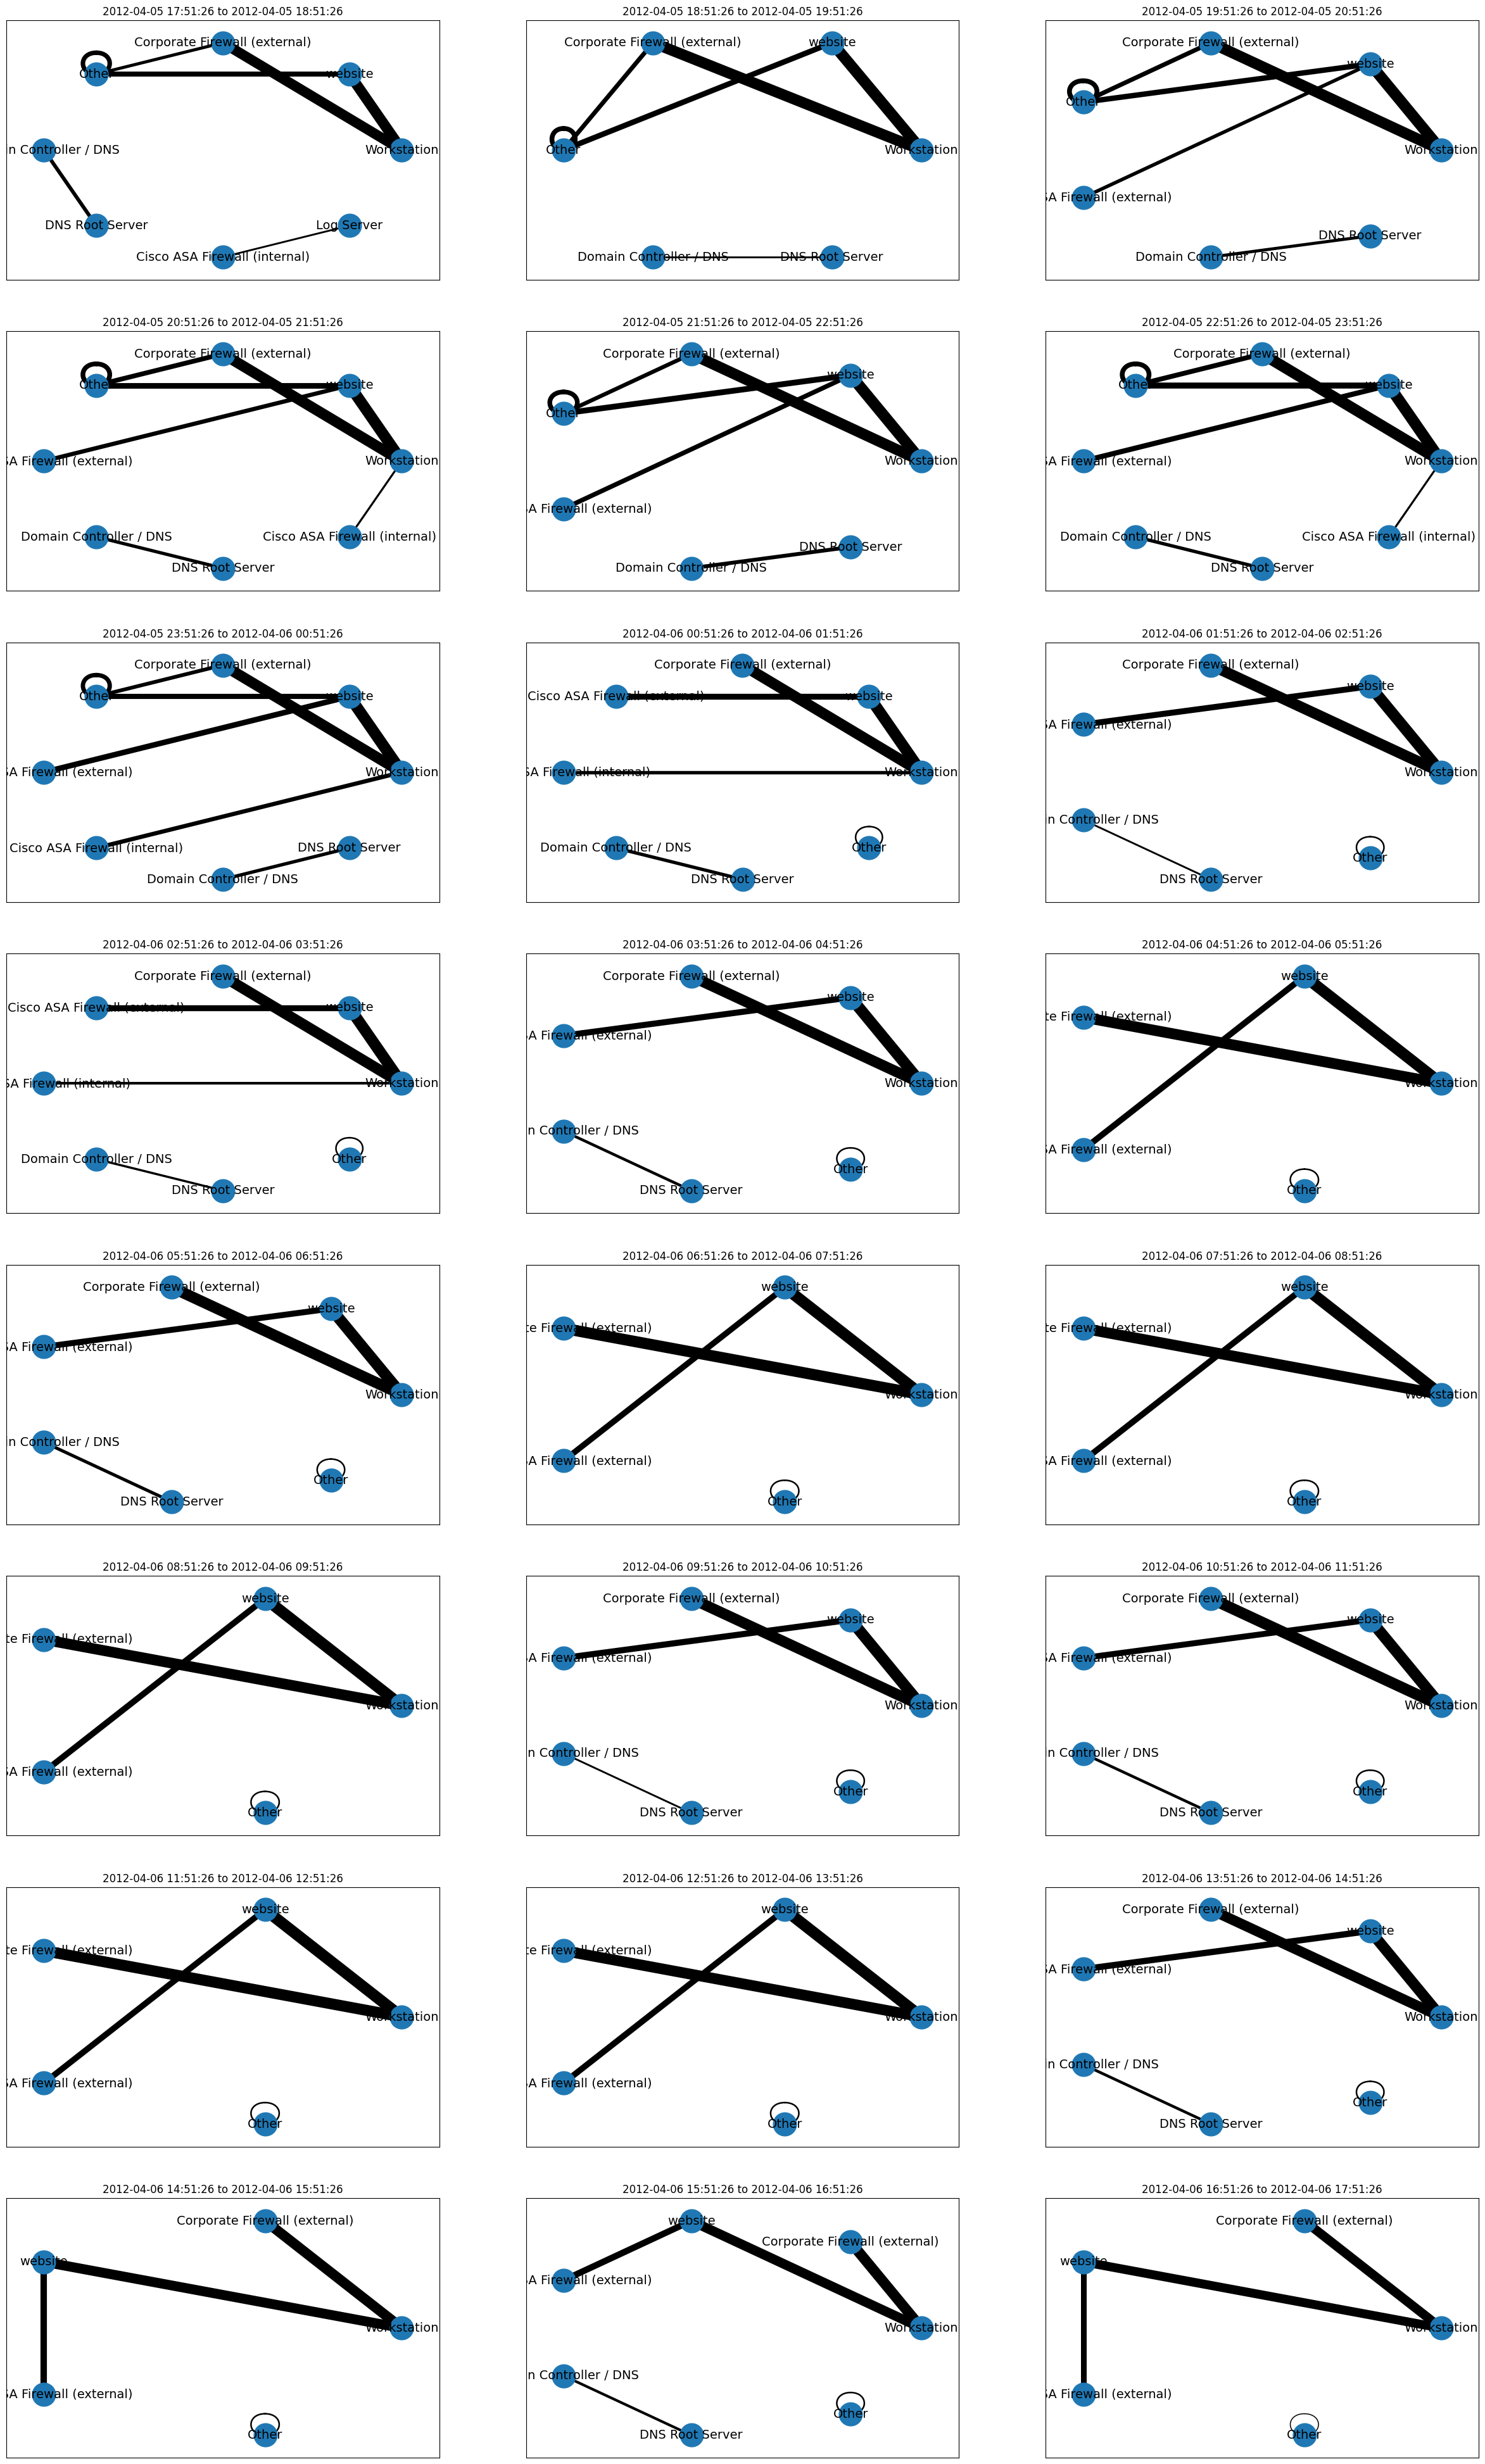

In [179]:
fig, axes = plt.subplots(int(np.ceil(len(date_range_hourly)/3)), 3, figsize=(30,50))
for i,times in datetime_table.iterrows():
    graph_df = generate_frequency_table_for_timespan(times[0], times[1])

    G = nx.from_pandas_edgelist(graph_df, source='Source IP Type', target='Destination IP Type', edge_attr='weight')
    widths = np.array([w for *_, w in G.edges.data('weight')])

    pos = nx.circular_layout(G)  # positions for all nodes

    # nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, ax=axes[int(np.floor(i/3)), i%3])

    # edges
    nx.draw_networkx_edges(G, pos, width=widths, ax=axes[int(np.floor(i/3)), i%3])

    # labels
    nx.draw_networkx_labels(G, pos, font_size=14, font_family="sans-serif", ax=axes[int(np.floor(i/3)), i%3])
    axes[int(np.floor(i/3)), i%3].set_title(f"{times[0]} to {times[1]}")
plt.savefig('multiple_graphs')
plt.show()